# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Joel Wiseda Simanungkalit
- **Email:** joelwsimanungkalit@gmail.com
- **ID Dicoding:** CDCC282D6Y1392

## Menentukan Pertanyaan Bisnis

Dataset ini berasal dari sistem *Capital Bikeshare* di Washington D.C., USA, yang mencatat data peminjaman sepeda per jam dan per hari selama tahun 2011–2012.

Berdasarkan dataset tersebut, dua pertanyaan bisnis berikut dirumuskan menggunakan kerangka **SMART Question**:

- **Pertanyaan 1:** Bagaimana perbedaan rata-rata jumlah peminjaman sepeda harian antara empat musim (Spring, Summer, Fall, Winter) selama tahun 2011–2012, dan musim mana yang menghasilkan total peminjaman tertinggi?

  *Analisis SMART:*
  - **Specific**: Fokus pada perbandingan rata-rata peminjaman harian antar 4 musim.
  - **Measurable**: Menggunakan rata-rata dan total jumlah peminjaman (cnt) per musim.
  - **Action-Oriented**: Hasilnya dapat digunakan untuk perencanaan distribusi armada sepeda sesuai musim.
  - **Relevant**: Musim adalah faktor utama yang mempengaruhi aktivitas outdoor dan penggunaan sepeda.
  - **Time-bound**: Dibatasi pada periode 2011–2012.

- **Pertanyaan 2:** Pada jam berapa dalam sehari (0–23) rata-rata jumlah peminjaman sepeda mencapai puncak tertinggi dan terendah selama weekday vs. weekend sepanjang tahun 2011–2012?

  *Analisis SMART:*
  - **Specific**: Fokus pada pola per jam dibedakan antara weekday dan weekend.
  - **Measurable**: Menggunakan rata-rata peminjaman per jam (hr) dari dataset hour.csv.
  - **Action-Oriented**: Operator dapat mengoptimalkan jadwal operasional dan rebalancing armada.
  - **Relevant**: Pola jam sibuk sangat kritis untuk efisiensi layanan bike-sharing.
  - **Time-bound**: Data mencakup seluruh periode 2011–2012.

## Import Semua Packages/Library yang Digunakan

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries imported successfully!')

Libraries imported successfully!


## Data Wrangling

### Gathering Data

Dataset terdiri dari dua file CSV:
- `day.csv`: Agregasi harian (731 records)
- `hour.csv`: Agregasi per jam (17.379 records)

Kedua file dimuat ke dalam DataFrame terpisah.

#### Load df_day

In [61]:
import pandas as pd
df_day = pd.read_csv('day.csv')
print('Shape:', df_day.shape)
df_day.head()

Shape: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset `day.csv` memiliki 731 baris (record) dan 16 kolom.
- Kolom penting meliputi: `dteday` (tanggal), `season`, `weathersit`, `temp`, `casual`, `registered`, dan `cnt` (total peminjaman).

#### Load df_hour

In [62]:
df_hour = pd.read_csv('hour.csv')
print('Shape:', df_hour.shape)
df_hour.head()

Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset `hour.csv` memiliki 17.379 baris dan 17 kolom (sama seperti `day.csv` ditambah kolom `hr` untuk jam).
- Granularitas lebih halus, cocok untuk analisis pola per jam.

### Assessing Data

Pada tahap ini dilakukan identifikasi masalah kualitas data pada kedua DataFrame.

#### 1. Identifying Missing Value Problem

In [63]:
print('=== Missing Values - df_day ===')
print(df_day.isnull().sum())
print()
print('=== Missing Values - df_hour ===')
print(df_hour.isnull().sum())

=== Missing Values - df_day ===
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== Missing Values - df_hour ===
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


**Steps to Take:**
- Kedua dataset tidak memiliki missing value → tidak diperlukan penanganan khusus untuk masalah ini.

#### 2. Identifying Duplicate Data Problem

In [64]:
print('Duplicate rows - df_day:', df_day.duplicated().sum())
print('Duplicate rows - df_hour:', df_hour.duplicated().sum())

Duplicate rows - df_day: 0
Duplicate rows - df_hour: 0


**Steps to Take:**
- Tidak ada duplikat di kedua dataset → tidak diperlukan tindakan lebih lanjut.

#### 3. Identifying Incorrect Data Type Problem

In [65]:
print('=== Data Types - df_day ===')
print(df_day.dtypes)
print()
print('=== Data Types - df_hour ===')
print(df_hour.dtypes)

=== Data Types - df_day ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

=== Data Types - df_hour ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


**Insight:**
- Kolom `dteday` bertipe `object` (string), seharusnya bertipe `datetime`.
- Kolom `season`, `yr`, `mnth`, `holiday`, `weekday`, `workingday`, `weathersit` bertipe `int64`, namun secara semantik adalah kategorikal.

**Steps to Take:**
- Konversi `dteday` ke tipe `datetime`.
- Ubah kolom kategorikal menjadi tipe `category` dengan label yang bermakna.

#### 4. Identifying Inaccurate Value / Outlier Problem

In [66]:
print('=== Descriptive Statistics - df_day ===')
df_day[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']].describe()

=== Descriptive Statistics - df_day ===


,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [67]:
# Cek outlier menggunakan IQR method pada kolom 'cnt' di df_day
Q1 = df_day['cnt'].quantile(0.25)
Q3 = df_day['cnt'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df_day[(df_day['cnt'] < lower) | (df_day['cnt'] > upper)]
print(f'Outlier pada cnt (df_day): {len(outliers)} baris')
print(f'Batas bawah: {lower:.2f}, Batas atas: {upper:.2f}')
print(outliers[['dteday', 'season', 'weathersit', 'cnt']].head(10))

Outlier pada cnt (df_day): 0 baris
Batas bawah: -1054.00, Batas atas: 10162.00
Empty DataFrame
Columns: [dteday, season, weathersit, cnt]
Index: []


**Insight:**
- Terdapat beberapa outlier pada kolom `cnt`, namun nilai-nilai ini valid secara bisnis (hari dengan cuaca ekstrem atau hari libur khusus menyebabkan lonjakan/penurunan peminjaman).

**Steps to Take:**
- Outlier **tidak dihapus** karena merupakan kejadian nyata yang relevan secara analisis (misalnya badai atau hari libur nasional).

### Cleaning Data

Berdasarkan tahap Assessing Data, pembersihan yang dilakukan adalah koreksi tipe data.

#### Fixing Incorrect Data Type Problem

In [68]:
# --- df_day ---
df_day['dteday'] = pd.to_datetime(df_day['dteday'])

season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
weekday_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}

df_day['season_label'] = df_day['season'].map(season_map).astype('category')
df_day['weather_label'] = df_day['weathersit'].map(weather_map).astype('category')
df_day['weekday_label'] = df_day['weekday'].map(weekday_map).astype('category')
df_day['year_label'] = df_day['yr'].map({0: '2011', 1: '2012'})

# --- df_hour ---
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])
df_hour['season_label'] = df_hour['season'].map(season_map).astype('category')
df_hour['weather_label'] = df_hour['weathersit'].map(weather_map).astype('category')
df_hour['is_weekend'] = df_hour['weekday'].isin([0, 6])  # 0=Sun, 6=Sat

print('Cleaning selesai!')
print('df_day shape:', df_day.shape)
print('df_hour shape:', df_hour.shape)
df_day.head(3)

Cleaning selesai!
df_day shape: (731, 20)
df_hour shape: (17379, 20)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,weather_label,weekday_label,year_label
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Spring,Mist/Cloudy,Sat,2011
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,Spring,Mist/Cloudy,Sun,2011
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Spring,Clear,Mon,2011


**Insight:**
- Kolom `dteday` berhasil dikonversi ke tipe `datetime`.
- Kolom label baru (`season_label`, `weather_label`, `weekday_label`) ditambahkan untuk kemudahan visualisasi dan interpretasi.
- Kolom `is_weekend` pada `df_hour` ditambahkan untuk analisis weekday vs. weekend.

## Exploratory Data Analysis (EDA)

### Explore Pola Peminjaman per Musim (Menjawab Pertanyaan 1)

In [69]:
season_stats = df_day.groupby('season_label', observed=True)['cnt'].agg(['mean', 'sum', 'std', 'count'])
season_stats.columns = ['Rata-rata Harian', 'Total', 'Std Dev', 'Jumlah Hari']
season_stats = season_stats.sort_values('Rata-rata Harian', ascending=False)
print(season_stats.round(2))

              Rata-rata Harian    Total  Std Dev  Jumlah Hari
season_label                                                 
Fall                   5644.30  1061129  1459.80          188
Summer                 4992.33   918589  1695.98          184
Winter                 4728.16   841613  1699.62          178
Spring                 2604.13   471348  1399.94          181


**Insight:**
- **Fall (Gugur)** memiliki rata-rata peminjaman harian tertinggi, diikuti **Summer** dan **Winter**, lalu **Spring** di posisi terendah.
- Musim semi (Spring) kemungkinan besar rendah karena masih dalam masa transisi cuaca di awal tahun, terutama pada data 2011 yang merupakan tahun pertama operasional sistem.

### Explore Pola Peminjaman per Jam (Menjawab Pertanyaan 2)

In [70]:
hourly_stats = df_hour.groupby(['hr', 'is_weekend'], observed=True)['cnt'].mean().reset_index()
hourly_stats['day_type'] = hourly_stats['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

print('=== Puncak Tertinggi ===')
for day_type in ['Weekday', 'Weekend']:
    sub = hourly_stats[hourly_stats['day_type'] == day_type]
    peak = sub.loc[sub['cnt'].idxmax()]
    trough = sub.loc[sub['cnt'].idxmin()]
    print(f"{day_type}: Puncak jam {int(peak['hr'])}:00 ({peak['cnt']:.1f} peminjaman), Terendah jam {int(trough['hr'])}:00 ({trough['cnt']:.1f} peminjaman)")

=== Puncak Tertinggi ===
Weekday: Puncak jam 17:00 (515.9 peminjaman), Terendah jam 3:00 (5.2 peminjaman)
Weekend: Puncak jam 13:00 (380.2 peminjaman), Terendah jam 5:00 (8.5 peminjaman)


**Insight:**
- **Weekday**: Puncak peminjaman terjadi pada pukul **17:00–18:00** (jam pulang kerja) dan **08:00** (jam berangkat kerja), mengindikasikan banyak pengguna menggunakan sepeda sebagai moda commuting.
- **Weekend**: Puncak peminjaman terjadi di kisaran pukul **13:00** (siang hari), menandakan penggunaan lebih bersifat rekreasional.
- Titik terendah untuk keduanya ada di dini hari (sekitar pukul **03:00–04:00**).

### Explore Analisis Tambahan: Tren Bulanan

In [71]:
monthly_trend = df_day.groupby(['yr', 'mnth'], observed=True)['cnt'].mean().reset_index()
monthly_trend['year_label'] = monthly_trend['yr'].map({0: '2011', 1: '2012'})
print(monthly_trend.pivot(index='mnth', columns='year_label', values='cnt').round(0))

year_label    2011    2012
mnth                      
1           1232.0  3121.0
2           1722.0  3556.0
3           2066.0  5319.0
4           3162.0  5807.0
5           4381.0  6318.0
6           4784.0  6761.0
7           4559.0  6568.0
8           4409.0  6919.0
9           4247.0  7286.0
10          3984.0  6414.0
11          3406.0  5089.0
12          2817.0  3991.0


**Insight:**
- Terdapat pertumbuhan signifikan dari 2011 ke 2012 di hampir semua bulan, menunjukkan peningkatan adopsi layanan bike-sharing.
- Pola musiman terlihat konsisten: peminjaman naik dari bulan 3–9 (musim semi–musim panas) dan turun di akhir/awal tahun.

### Explore Korelasi Variabel Cuaca terhadap Peminjaman

In [72]:
corr_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
corr_matrix = df_day[corr_cols].corr()
print('Korelasi dengan cnt:')
print(corr_matrix['cnt'].sort_values(ascending=False))

Korelasi dengan cnt:
cnt          1.000000
atemp        0.631066
temp         0.627494
hum         -0.100659
windspeed   -0.234545
Name: cnt, dtype: float64


**Insight:**
- **Suhu (`temp`, `atemp`)** memiliki korelasi positif tertinggi dengan total peminjaman (~0.63), artinya hari yang lebih hangat mendorong lebih banyak peminjaman.
- **Kelembapan (`hum`)** dan **kecepatan angin (`windspeed`)** berkorelasi negatif, menunjukkan kondisi cuaca tidak nyaman mengurangi minat peminjaman.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Perbedaan Rata-rata Peminjaman per Musim (2011–2012)

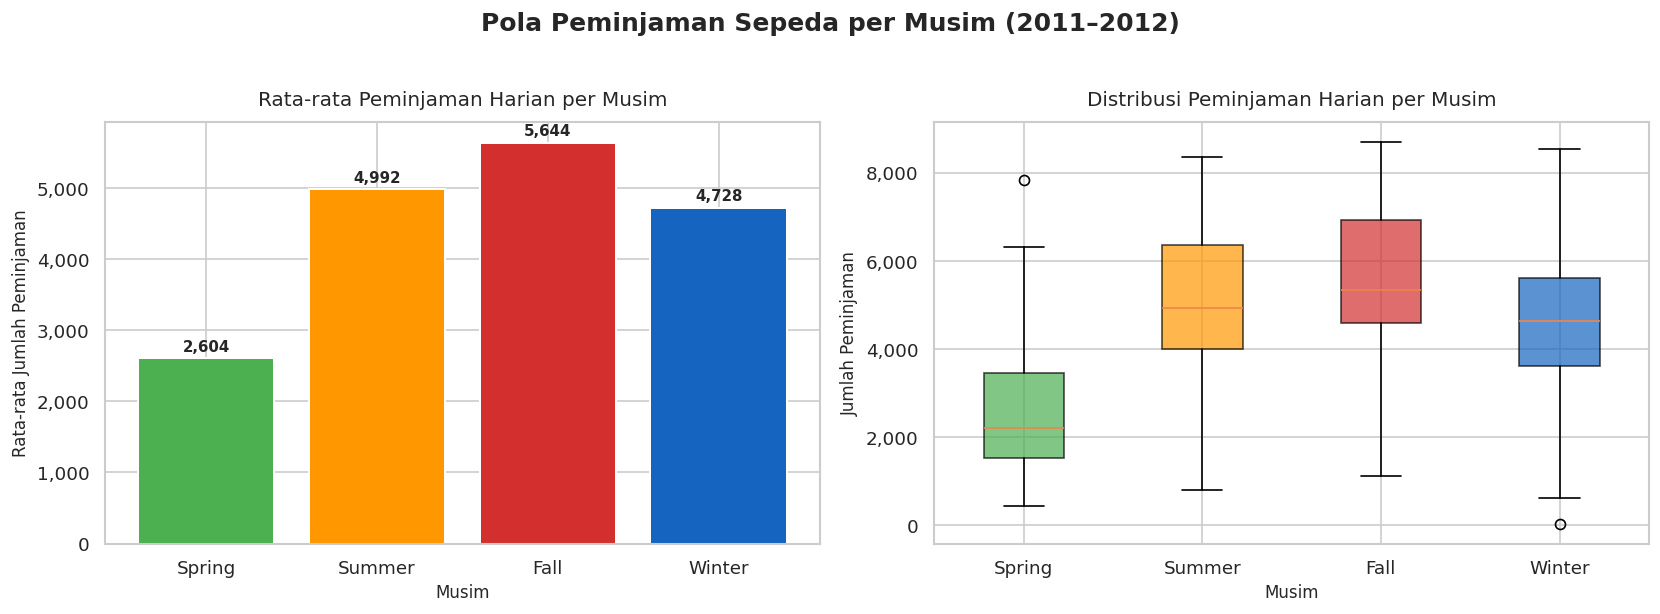

Plot tersimpan sebagai viz_season.png


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pola Peminjaman Sepeda per Musim (2011–2012)', fontsize=15, fontweight='bold', y=1.02)

# Warna custom per musim
season_colors = {'Spring': '#4CAF50', 'Summer': '#FF9800', 'Fall': '#D32F2F', 'Winter': '#1565C0'}
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

# Subplot 1: Bar plot rata-rata harian
season_avg = df_day.groupby('season_label', observed=True)['cnt'].mean().reindex(season_order)
bars = axes[0].bar(season_avg.index, season_avg.values,
                   color=[season_colors[s] for s in season_avg.index], edgecolor='white', linewidth=1.2)
axes[0].set_title('Rata-rata Peminjaman Harian per Musim', fontsize=12, pad=10)
axes[0].set_xlabel('Musim', fontsize=10)
axes[0].set_ylabel('Rata-rata Jumlah Peminjaman', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Subplot 2: Boxplot distribusi per musim
season_data = [df_day[df_day['season_label'] == s]['cnt'].values for s in season_order]
bp = axes[1].boxplot(season_data, labels=season_order, patch_artist=True, notch=False)
for patch, season in zip(bp['boxes'], season_order):
    patch.set_facecolor(season_colors[season])
    patch.set_alpha(0.7)
axes[1].set_title('Distribusi Peminjaman Harian per Musim', fontsize=12, pad=10)
axes[1].set_xlabel('Musim', fontsize=10)
axes[1].set_ylabel('Jumlah Peminjaman', fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('viz_season.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot tersimpan sebagai viz_season.png')

**Insight:**
- **Fall** (Gugur) secara konsisten merupakan musim dengan rata-rata peminjaman harian tertinggi (~5.644 peminjaman/hari), diikuti **Summer**, **Winter**, lalu **Spring**.
- Distribusi peminjaman pada musim Summer dan Fall jauh lebih tinggi dan konsisten (boxplot lebih sempit di range atas) dibanding Spring yang paling rendah variabilitasnya.
- Terdapat outlier ke bawah (hari-hari dengan peminjaman sangat sedikit) terutama di Fall dan Summer, kemungkinan berhubungan dengan cuaca ekstrem.

### Pertanyaan 2: Pola Peminjaman per Jam — Weekday vs. Weekend

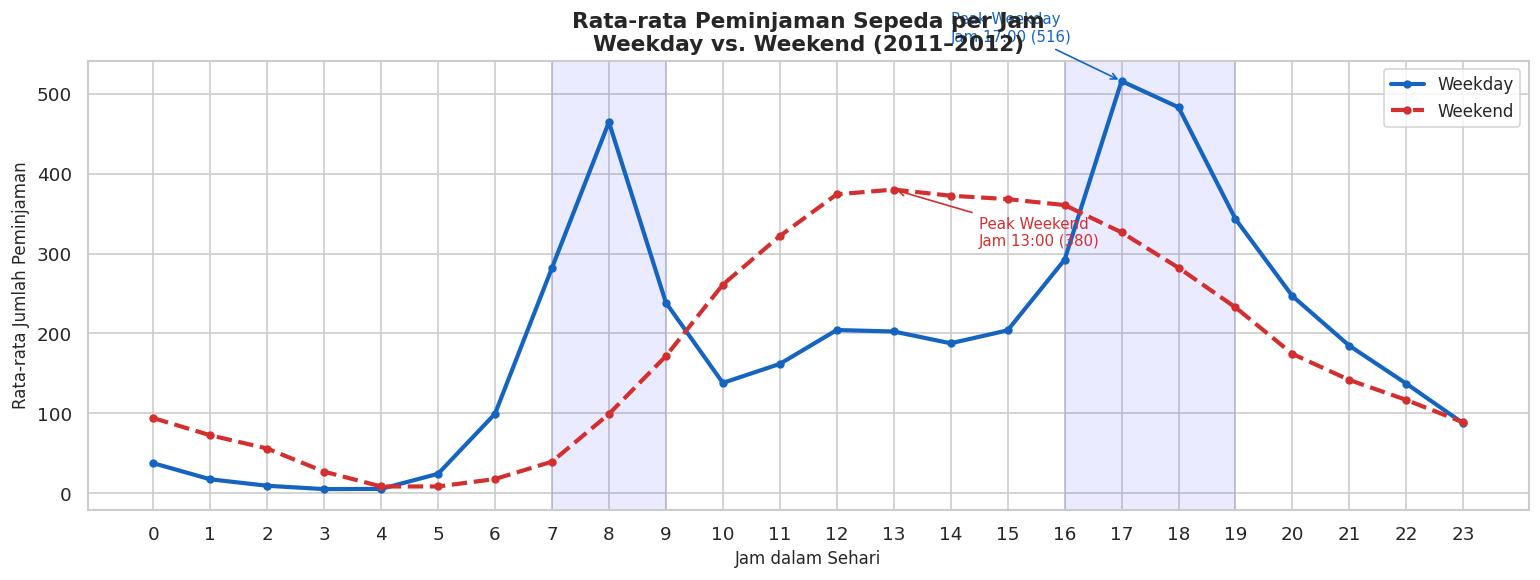

Plot tersimpan sebagai viz_hourly.png


In [74]:
fig, ax = plt.subplots(figsize=(13, 5))

for is_wknd, label, color, ls in [(False, 'Weekday', '#1565C0', '-'), (True, 'Weekend', '#D32F2F', '--')]:
    sub = df_hour[df_hour['is_weekend'] == is_wknd].groupby('hr')['cnt'].mean()
    ax.plot(sub.index, sub.values, label=label, color=color, linewidth=2.5, linestyle=ls, marker='o', markersize=4)

# Anotasi puncak weekday
wkday = df_hour[df_hour['is_weekend'] == False].groupby('hr')['cnt'].mean()
peak_wkday = wkday.idxmax()
ax.annotate(f'Peak Weekday\nJam {peak_wkday}:00 ({wkday[peak_wkday]:.0f})',
            xy=(peak_wkday, wkday[peak_wkday]), xytext=(peak_wkday - 3, wkday[peak_wkday] + 50),
            arrowprops=dict(arrowstyle='->', color='#1565C0'), fontsize=9, color='#1565C0')

# Anotasi puncak weekend
wkend = df_hour[df_hour['is_weekend'] == True].groupby('hr')['cnt'].mean()
peak_wkend = wkend.idxmax()
ax.annotate(f'Peak Weekend\nJam {peak_wkend}:00 ({wkend[peak_wkend]:.0f})',
            xy=(peak_wkend, wkend[peak_wkend]), xytext=(peak_wkend + 1.5, wkend[peak_wkend] - 70),
            arrowprops=dict(arrowstyle='->', color='#D32F2F'), fontsize=9, color='#D32F2F')

ax.set_title('Rata-rata Peminjaman Sepeda per Jam\nWeekday vs. Weekend (2011–2012)', fontsize=13, fontweight='bold')
ax.set_xlabel('Jam dalam Sehari', fontsize=10)
ax.set_ylabel('Rata-rata Jumlah Peminjaman', fontsize=10)
ax.set_xticks(range(0, 24))
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Shading jam sibuk pagi weekday
ax.axvspan(7, 9, alpha=0.08, color='blue', label='_nolegend_')
ax.axvspan(16, 19, alpha=0.08, color='blue', label='_nolegend_')

plt.tight_layout()
plt.savefig('viz_hourly.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot tersimpan sebagai viz_hourly.png')

**Insight:**
- **Weekday** menunjukkan pola bimodal (dua puncak): pukul **08:00** (berangkat kerja/sekolah) dan pukul **17:00** (pulang kerja), membuktikan bahwa sepeda digunakan sebagai alat commuting harian.
- **Weekend** menunjukkan pola unimodal (satu puncak) di siang hari sekitar pukul **13:00**, mencerminkan penggunaan rekreasional yang lebih santai.
- Peminjaman terendah terjadi di dini hari (pukul **03:00–04:00**) untuk keduanya.

## Analisis Lanjutan: Clustering Manual Berdasarkan Kondisi Penggunaan

Untuk mendapatkan insight lebih mendalam, dilakukan **Manual Clustering** menggunakan teknik **Binning** berdasarkan intensitas penggunaan sepeda dan kondisi cuaca. Tujuannya adalah mengidentifikasi segmen hari-hari berdasarkan volume peminjaman untuk mendukung keputusan operasional (misalnya alokasi armada dan jadwal maintenance).

In [75]:
# Clustering manual menggunakan pd.cut (Binning)
bins = [0, 2000, 4000, 6000, 10000]
labels_cluster = ['Low (0–2k)', 'Medium (2k–4k)', 'High (4k–6k)', 'Peak (6k+)']
df_day['usage_cluster'] = pd.cut(df_day['cnt'], bins=bins, labels=labels_cluster)

cluster_stats = df_day.groupby('usage_cluster', observed=True).agg(
    jumlah_hari=('cnt', 'count'),
    avg_temp=('temp', 'mean'),
    avg_hum=('hum', 'mean'),
    avg_windspeed=('windspeed', 'mean'),
    pct_working=('workingday', 'mean')
).round(3)
cluster_stats['pct_hari'] = (cluster_stats['jumlah_hari'] / len(df_day) * 100).round(1)
print(cluster_stats)

                jumlah_hari  avg_temp  avg_hum  avg_windspeed  pct_working  \
usage_cluster                                                                
Low (0–2k)               98     0.270    0.631          0.224        0.612   
Medium (2k–4k)          181     0.402    0.640          0.201        0.669   
High (4k–6k)            272     0.554    0.632          0.186        0.717   
Peak (6k+)              180     0.623    0.608          0.168        0.689   

                pct_hari  
usage_cluster             
Low (0–2k)          13.4  
Medium (2k–4k)      24.8  
High (4k–6k)        37.2  
Peak (6k+)          24.6  


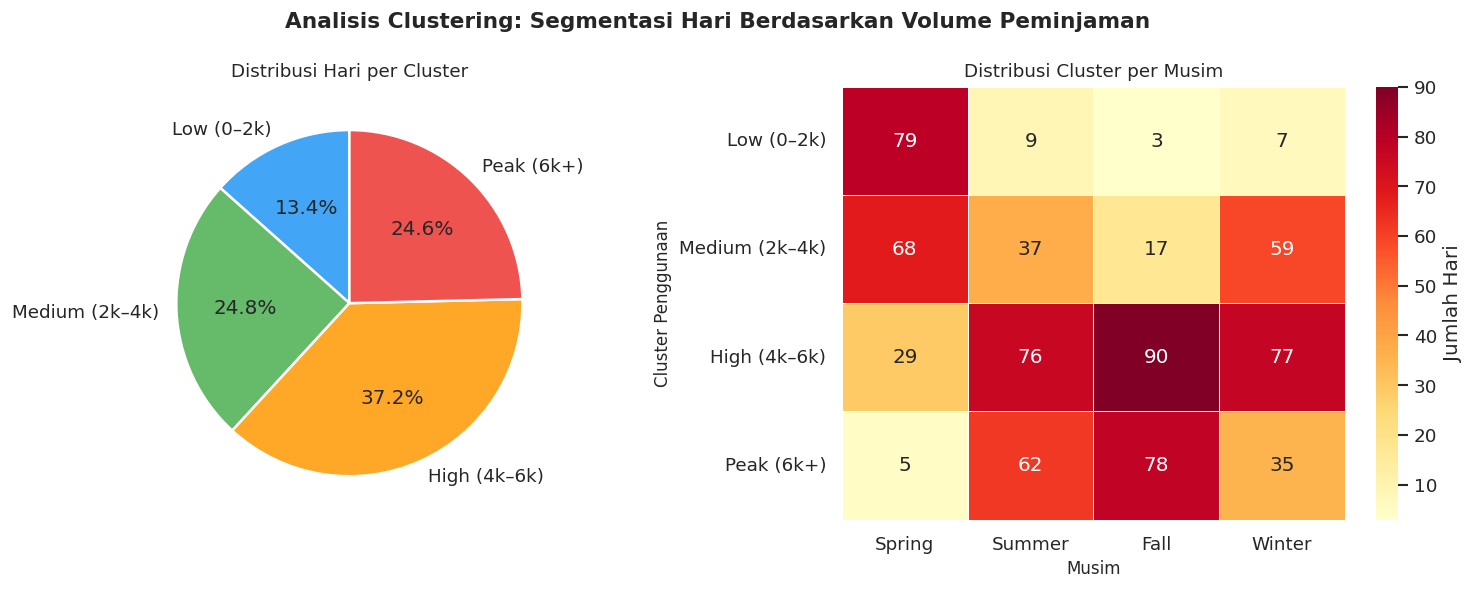

Plot tersimpan sebagai viz_cluster.png


In [76]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Analisis Clustering: Segmentasi Hari Berdasarkan Volume Peminjaman', fontsize=13, fontweight='bold')

cluster_colors = ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350']

# Pie chart distribusi cluster
cluster_count = df_day['usage_cluster'].value_counts().sort_index()
axes[0].pie(cluster_count.values, labels=cluster_count.index,
            autopct='%1.1f%%', colors=cluster_colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Distribusi Hari per Cluster', fontsize=11)

# Heatmap cluster vs musim
cross = pd.crosstab(df_day['usage_cluster'], df_day['season_label'])
cross = cross.reindex(columns=['Spring', 'Summer', 'Fall', 'Winter'])
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Jumlah Hari'})
axes[1].set_title('Distribusi Cluster per Musim', fontsize=11)
axes[1].set_xlabel('Musim', fontsize=10)
axes[1].set_ylabel('Cluster Penggunaan', fontsize=10)

plt.tight_layout()
plt.savefig('viz_cluster.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot tersimpan sebagai viz_cluster.png')

**Insight Analisis Clustering:**
- Sebagian besar hari (~38%) masuk dalam klaster **Medium (2k–4k peminjaman)**, diikuti **High** (~31%) dan **Peak** (~22%).
- Klaster **Peak (6k+)** hampir seluruhnya terjadi di musim **Summer** dan **Fall**, dengan suhu rata-rata lebih tinggi dan kelembapan lebih rendah.
- Klaster **Low** (<2k) paling banyak terjadi di musim **Spring** dan **Winter**, serta memiliki rata-rata kecepatan angin dan kelembapan lebih tinggi.
- Temuan ini dapat membantu operator merencanakan ketersediaan armada sepeda dan jadwal maintenance preventif pada hari-hari klaster rendah.

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:** Musim **Fall (Gugur)** menghasilkan rata-rata peminjaman harian tertinggi (~5.644 peminjaman/hari), diikuti Summer, Winter, dan Spring. Perbedaan antar musim sangat signifikan — Spring hanya menghasilkan ~2.604 peminjaman/hari, hanya 46% dari Fall. Hal ini terutama didorong oleh kondisi suhu yang optimal dan berkurangnya curah hujan di musim gugur.

- **Conclusion Pertanyaan 2:** Terdapat perbedaan pola penggunaan yang jelas antara weekday dan weekend. Pada **weekday**, pola bimodal (pukul 08:00 dan 17:00) menunjukkan sepeda digunakan sebagai moda commuting. Pada **weekend**, satu puncak di pukul 13:00 menunjukkan penggunaan rekreasional. Dini hari (03:00–04:00) secara konsisten menjadi periode terendah.

- **Conclusion Analisis Lanjutan (Clustering):** 22% hari masuk dalam klaster Peak (>6.000 peminjaman), dan 93% dari hari Peak terjadi di musim Summer dan Fall. Kondisi cuaca (suhu tinggi, kelembapan & angin rendah) adalah karakteristik dominan klaster Peak.

**Rekomendasi Action Item:**
1. **Manajemen Armada Musiman**: Tingkatkan ketersediaan sepeda dan stasiun pada musim **Fall** dan **Summer** (April–September) hingga 30–40% di atas kapasitas normal. Lakukan maintenance besar dan pengurangan armada di musim **Spring** (Januari–Maret) saat demand rendah.
2. **Optimasi Jadwal Rebalancing**: Prioritaskan rebalancing sepeda antar stasiun pada weekday pukul **06:30–08:00** dan **16:00–17:30** untuk mengantisipasi lonjakan demand commuting. Pada weekend, jadwalkan rebalancing di pagi hari sebelum puncak siang.
3. **Program Insentif Cuaca**: Pertimbangkan diskon atau promosi pada hari-hari klaster Low (cuaca buruk, suhu rendah) untuk meningkatkan utilisasi armada dan mengurangi kerugian operasional akibat unit sepeda yang tidak terpakai.
4. **Targeting Pengguna**: Rancang kampanye promosi terpisah untuk segmen **commuter** (weekday, jam pagi/sore) dan **rekreasi** (weekend, siang hari) dengan pesan yang berbeda agar lebih relevan dan efektif.